# PRE-MATCH WINNER PREDICTION

## Import Libraries and Load Dataset

In [70]:
import pandas as pd
import numpy as np

matches=pd.read_csv('matches.csv')
deliveries=pd.read_csv('deliveries.csv')

print("Matches Shape:",matches.shape)
print("Deliveries Shape:",deliveries.shape)


Matches Shape: (1095, 20)
Deliveries Shape: (260920, 17)


In [71]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [72]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [73]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [74]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [75]:
print("Missing Values",matches.isnull().sum())

Missing Values id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


## Clean Matches Dataset

In [76]:
# Remove matches where winner is missing (No Result / Abandoned)
matches_clean=matches.dropna(subset=['winner'])

print("Before Cleaning",matches.shape)
print("After Cleaning",matches_clean.shape)


Before Cleaning (1095, 20)
After Cleaning (1090, 20)


In [77]:
matches_clean.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


## Standardize Team Names (Old -> New)

In [78]:
df=matches_clean.copy()

#Mapping old names to new names
team_name_map = {
    "Delhi Daredevils": "Delhi Capitals",
    "Rising Pune Supergiant": "Rising Pune Supergiants",
    
    # Deccan -> SRH
    "Deccan Chargers": "Sunrisers Hyderabad",

    # Kings XI -> Punjab Kings
    "Kings XI Punjab": "Punjab Kings",

    #Royal Challengers Bangalore -> Royal Challengers Bengaluru
    "Royal Challengers Bangalore" : "Royal Challengers Bengaluru"
    
}

# Replace names in important columns
cols_to_fix = ["team1", "team2", "toss_winner", "winner"]

for col in cols_to_fix:
    df[col] = df[col].replace(team_name_map)

# Check unique teams after fixing
teams = pd.unique(df[["team1", "team2"]].values.ravel())

print("Total unique teams after mapping:",len(teams))
print("Teams:",sorted(teams))


Total unique teams after mapping: 14
Teams: ['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiants', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


## Toss Decision Impact Analysis

Venue-wise Toss Impact (Top 10 Venues):
toss_decision                                     bat      field
venue                                                           
Dubai International Cricket Stadium         36.842105  40.740741
Eden Gardens                                42.857143  63.265306
Feroz Shah Kotla                            48.000000  55.882353
M Chinnaswamy Stadium                       37.500000  58.181818
MA Chidambaram Stadium, Chepauk             61.764706  28.571429
Punjab Cricket Association Stadium, Mohali  35.714286  52.380952
Rajiv Gandhi International Stadium, Uppal   21.739130  46.153846
Sawai Mansingh Stadium                      31.578947  67.857143
Wankhede Stadium                            50.000000  50.980392
Wankhede Stadium, Mumbai                    37.500000  59.459459


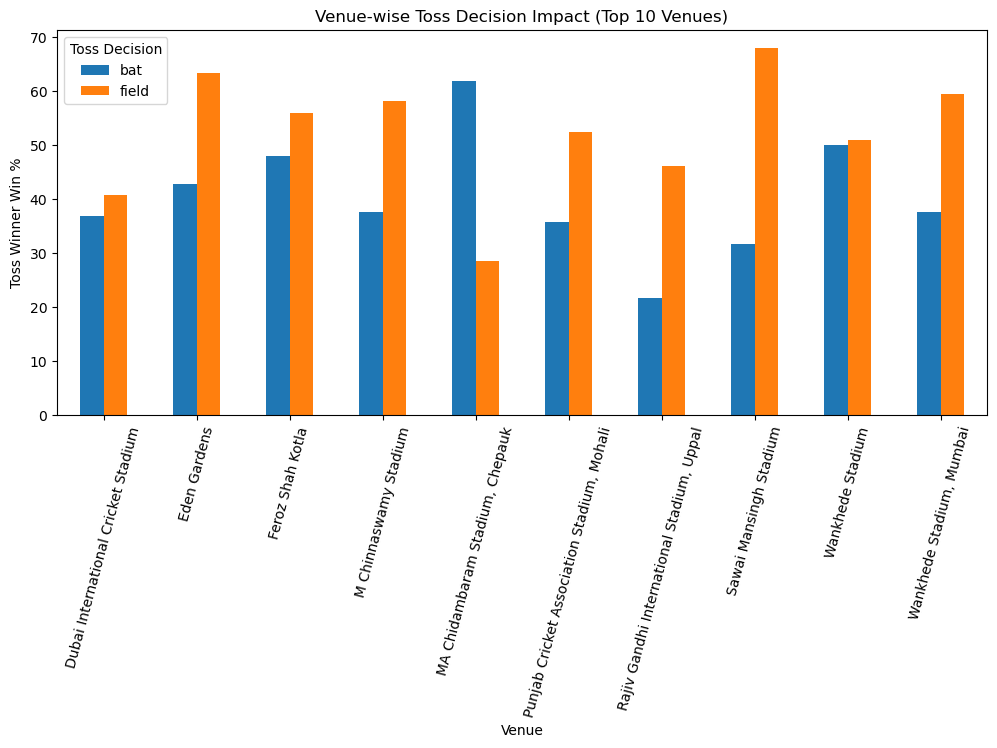

In [79]:
import matplotlib.pyplot as plt

# 1 = toss winner also won the match, else 0
df["toss_winner_won_match"] = (df["toss_winner"] == df["winner"]).astype(int)

# Group by venue + toss decision and calculate win %
venue_toss_impact = (
    df.groupby(["venue", "toss_decision"])["toss_winner_won_match"]
    .mean()
    .reset_index()
)


venue_toss_impact["win_percent"] = venue_toss_impact["toss_winner_won_match"] * 100


top_venues = df["venue"].value_counts().head(10).index
venue_toss_impact = venue_toss_impact[venue_toss_impact["venue"].isin(top_venues)]


pivot_df = venue_toss_impact.pivot(index="venue", columns="toss_decision", values="win_percent")

print("Venue-wise Toss Impact (Top 10 Venues):")
print(pivot_df)

# Plot
pivot_df.plot(kind="bar", figsize=(12,5))
plt.title("Venue-wise Toss Decision Impact (Top 10 Venues)")
plt.xlabel("Venue")
plt.ylabel("Toss Winner Win %")
plt.xticks(rotation=75)
plt.legend(title="Toss Decision")
plt.show()


## Select Features(X) and Target(y)

In [80]:
features=["team1","team2","city","toss_winner","toss_decision","season"]
target="winner"

#X=Input label,Y=Output label
X=df[features]
y=df[target]

print("X shape:",X.shape)
print("y shape:",y.shape)

X shape: (1090, 6)
y shape: (1090,)


In [81]:
X.head()

,team1,team2,city,toss_winner,toss_decision,season
0,Royal Challengers Bengaluru,Kolkata Knight Riders,Bangalore,Royal Challengers Bengaluru,field,2007/08
1,Punjab Kings,Chennai Super Kings,Chandigarh,Chennai Super Kings,bat,2007/08
2,Delhi Capitals,Rajasthan Royals,Delhi,Rajasthan Royals,bat,2007/08
3,Mumbai Indians,Royal Challengers Bengaluru,Mumbai,Mumbai Indians,bat,2007/08
4,Kolkata Knight Riders,Sunrisers Hyderabad,Kolkata,Sunrisers Hyderabad,bat,2007/08


## Train/Test Split and OneHotEncoding Setup

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

#Split data into train and test
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

#Categorical Columns(All are text-based)
cat_cols=X.columns.tolist()

#OneHotEncode Categorical Columns(Converts text data into numbers)
preprocessor=ColumnTransformer(                        #ColumnTransformer applies encoding properly to your feature columns.
    transformers=[
        ("cat",OneHotEncoder(handle_unknown="ignore"),cat_cols)
    ]
)
print("Train size:",X_train.shape)
print("Test size:",X_test.shape)


Train size: (872, 6)
Test size: (218, 6)


## Train Random Forest Model

## 

In [83]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

#Creating ML Pipeline(encoding+model)
model=Pipeline(steps=[              #Pipeline combines steps in proper order
    ("preprocessor",preprocessor),   #Preprocessor converts texts into numbers(OneHotEncoding)
    ("classifier",RandomForestClassifier(n_estimators=200,random_state=42))
])

model.fit(X_train,y_train)
print("Model Training Completed")

Model Training Completed


## Evaluate Model Performance

In [84]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

#Predict on test data
y_pred=model.predict(X_test)         #Predicts winner for unseen matches

#Accuracy
acc=accuracy_score(y_test,y_pred)    #Overall Correct Prediction %
print("\nModel Accuracy:",round(acc*100,2),"%")

#Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test,y_pred))

#Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test,y_pred))     #Shows where model is confusing between teams



Model Accuracy: 55.05 %

Classification Report:

                             precision    recall  f1-score   support

        Chennai Super Kings       0.54      0.68      0.60        28
             Delhi Capitals       0.37      0.30      0.33        23
              Gujarat Lions       1.00      0.33      0.50         3
             Gujarat Titans       0.83      0.83      0.83         6
       Kochi Tuskers Kerala       0.00      0.00      0.00         1
      Kolkata Knight Riders       0.68      0.73      0.70        26
       Lucknow Super Giants       0.33      0.20      0.25         5
             Mumbai Indians       0.56      0.66      0.60        29
              Pune Warriors       0.00      0.00      0.00         2
               Punjab Kings       0.50      0.18      0.27        22
           Rajasthan Royals       0.48      0.45      0.47        22
    Rising Pune Supergiants       1.00      0.67      0.80         3
Royal Challengers Bengaluru       0.53      0.64    

c:\Users\sujal\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\sujal\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\sujal\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [85]:
#Runs scored by each team in each match
team_runs=deliveries.groupby(["match_id","batting_team"])["total_runs"].sum().reset_index()
team_runs.columns=["match_id","team","runs_scored"]

#Wickets lost my each team in each match
team_wkts=deliveries.groupby(["match_id","batting_team"])["is_wicket"].sum().reset_index()
team_wkts.columns=["match_id","team","wickets_lost"]

team_stats=pd.merge(team_runs,team_wkts,on=["match_id","team"])

team_stats.head()

,match_id,team,runs_scored,wickets_lost
0,335982,Kolkata Knight Riders,222,3
1,335982,Royal Challengers Bangalore,82,10
2,335983,Chennai Super Kings,240,5
3,335983,Kings XI Punjab,207,4
4,335984,Delhi Daredevils,132,1


In [86]:
team_avg=team_stats.groupby("team")[["runs_scored","wickets_lost"]].mean().reset_index()
team_avg.columns=["team","avg_runs_scored","avg_wickets_lost"]

team_avg.head()

,team,avg_runs_scored,avg_wickets_lost
0,Chennai Super Kings,162.991561,5.253165
1,Deccan Chargers,152.840000,6.453333
2,Delhi Capitals,163.736264,6.263736
3,Delhi Daredevils,150.906832,5.913043
4,Gujarat Lions,162.066667,6.266667


In [87]:
df_form = df.sort_values(["season", "id"]).copy()


team1_data = df_form[["id", "season", "team1", "winner"]].copy()
team1_data = team1_data.rename(columns={"team1": "team"})

team2_data = df_form[["id", "season", "team2", "winner"]].copy()
team2_data = team2_data.rename(columns={"team2": "team"})

long_df = pd.concat([team1_data, team2_data], ignore_index=True)

# Win = 1 if team won else 0
long_df["win"] = (long_df["team"] == long_df["winner"]).astype(int)


long_df["last5_winrate"] = (
    long_df.groupby("team")["win"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)


team1_form = long_df[["id", "team", "last5_winrate"]].rename(
    columns={"team": "team1", "last5_winrate": "team1_last5_winrate"}
)


team2_form = long_df[["id", "team", "last5_winrate"]].rename(
    columns={"team": "team2", "last5_winrate": "team2_last5_winrate"}
)

df3 = df_form.merge(team1_form, on=["id", "team1"], how="left")
df3 = df3.merge(team2_form, on=["id", "team2"], how="left")


df3["team1_last5_winrate"] = df3["team1_last5_winrate"].fillna(0.5)
df3["team2_last5_winrate"] = df3["team2_last5_winrate"].fillna(0.5)

df3[["team1", "team2", "team1_last5_winrate", "team2_last5_winrate"]].head()


,team1,team2,team1_last5_winrate,team2_last5_winrate
0,Royal Challengers Bengaluru,Kolkata Knight Riders,0.5,0.8
1,Punjab Kings,Chennai Super Kings,0.5,0.4
2,Delhi Capitals,Rajasthan Royals,0.5,0.4
3,Mumbai Indians,Royal Challengers Bengaluru,0.5,0.8
4,Kolkata Knight Riders,Sunrisers Hyderabad,0.5,0.4


In [88]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

features3 = ["team1", "team2", "venue", "toss_winner", "toss_decision", "season",
             "team1_last5_winrate", "team2_last5_winrate"]

X3 = df3[features3]
y3 = df3["winner"]

X_train, X_test, y_train, y_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

cat_cols = ["team1", "team2", "venue", "toss_winner", "toss_decision","season"]
num_cols = ["team1_last5_winrate", "team2_last5_winrate"]

preprocessor2 = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

rf_model2 = Pipeline(steps=[
    ("preprocessor", preprocessor2),
    ("classifier", RandomForestClassifier(n_estimators=300, random_state=42))
])

rf_model2.fit(X_train, y_train)
y_pred = rf_model2.predict(X_test)

acc2 = accuracy_score(y_test, y_pred)
print("Accuracy with Last 5 Matches Form:", round(acc2 * 100, 2), "%")


Accuracy with Last 5 Matches Form: 54.59 %


## Sample Prediction + Win Probability (%)

In [89]:
import pandas as pd
import numpy as np

sample_match = pd.DataFrame([{
    "team1": "Chennai Super Kings",
    "team2": "Mumbai Indians",
    "venue": "Wankhede Stadium",
    "toss_winner": "Mumbai Indians",
    "toss_decision": "field",
    "season": "2019",
    "team1_last5_winrate": 0.6,
    "team2_last5_winrate": 0.8
}])

predicted_winner = rf_model2.predict(sample_match)[0]

proba = rf_model2.predict_proba(sample_match)[0]
classes = rf_model2.classes_

winner_prob = proba[list(classes).index(predicted_winner)] * 100

print("Predicted Winner:", predicted_winner)
print("Win Probability:", round(winner_prob, 2), "%")


Predicted Winner: Mumbai Indians
Win Probability: 65.67 %


# LIVE MATCH WIN PROBABILITY (Ball-by-Ball)

In [90]:
# Merge match winner + teams into deliveries
ball_df = deliveries.merge(
    matches_clean[["id", "winner", "team1", "team2"]],
    left_on="match_id",
    right_on="id",
    how="left"
)

# Drop extra column 'id'
ball_df.drop(columns=["id"], inplace=True)

ball_df.head()


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,winner,team1,team2
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore,Kolkata Knight Riders
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore,Kolkata Knight Riders
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore,Kolkata Knight Riders
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore,Kolkata Knight Riders
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore,Kolkata Knight Riders


## Filter 2nd Innings & Create Live Match Timeline

In [91]:
# Keep only 2nd innings data (chase innings)
chase_df = ball_df[ball_df["inning"] == 2].copy()


chase_df = chase_df.sort_values(["match_id", "over", "ball"])

#  Current score after each ball (cumulative)
chase_df["current_score"] = chase_df.groupby("match_id")["total_runs"].cumsum()

#  Wickets fallen after each ball (cumulative)
chase_df["wickets_fallen"] = chase_df.groupby("match_id")["is_wicket"].cumsum()

# Balls left in innings (20 overs = 120 balls)
chase_df["balls_done"] = chase_df.groupby("match_id").cumcount() + 1
chase_df["balls_left"] = 120 - chase_df["balls_done"]

chase_df[["match_id", "over", "ball", "total_runs", "current_score", "wickets_fallen", "balls_left"]].head(10)


,match_id,over,ball,total_runs,current_score,wickets_fallen,balls_left
124,335982,0,1,1,1,0,119
125,335982,0,2,1,2,0,118
126,335982,0,3,0,2,0,117
127,335982,0,4,1,3,0,116
128,335982,0,5,1,4,0,115
129,335982,0,6,0,4,0,114
130,335982,0,7,0,4,0,113
131,335982,1,1,0,4,1,112
132,335982,1,2,0,4,1,111
133,335982,1,3,4,8,1,110


## Target Score+Runs Left+Result Label

In [92]:
#  Target = 1st innings total score + 1
first_innings = ball_df[ball_df["inning"] == 1].copy()

target_df = first_innings.groupby("match_id")["total_runs"].sum().reset_index()
target_df.columns = ["match_id", "target"]
target_df["target"] = target_df["target"] + 1  # chase target


chase_df = chase_df.merge(target_df, on="match_id", how="left")

# Runs left to win
chase_df["runs_left"] = chase_df["target"] - chase_df["current_score"]

# Wickets left (10 wickets total)
chase_df["wickets_left"] = 10 - chase_df["wickets_fallen"]


# batting team in chase is in column "batting_team"
chase_df["result"] = (chase_df["batting_team"] == chase_df["winner"]).astype(int)

chase_df[["match_id", "batting_team", "bowling_team", "target", "current_score", "runs_left", "balls_left", "wickets_left", "result"]].head(10)


,match_id,batting_team,bowling_team,target,current_score,runs_left,balls_left,wickets_left,result
0,335982,Royal Challengers Bangalore,Kolkata Knight Riders,223,1,222,119,10,0
1,335982,Royal Challengers Bangalore,Kolkata Knight Riders,223,2,221,118,10,0
2,335982,Royal Challengers Bangalore,Kolkata Knight Riders,223,2,221,117,10,0
3,335982,Royal Challengers Bangalore,Kolkata Knight Riders,223,3,220,116,10,0
4,335982,Royal Challengers Bangalore,Kolkata Knight Riders,223,4,219,115,10,0
5,335982,Royal Challengers Bangalore,Kolkata Knight Riders,223,4,219,114,10,0
6,335982,Royal Challengers Bangalore,Kolkata Knight Riders,223,4,219,113,10,0
7,335982,Royal Challengers Bangalore,Kolkata Knight Riders,223,4,219,112,9,0
8,335982,Royal Challengers Bangalore,Kolkata Knight Riders,223,4,219,111,9,0
9,335982,Royal Challengers Bangalore,Kolkata Knight Riders,223,8,215,110,9,0


## Compute CRR and RRR(Live Features)

In [93]:
import numpy as np

# Current Run Rate (runs per over)
chase_df["crr"] = (chase_df["current_score"] * 6) / (120 - chase_df["balls_left"])

# Required Run Rate (runs needed per over)

chase_df["rrr"] = np.where(
    chase_df["balls_left"] > 0,
    (chase_df["runs_left"] * 6) / chase_df["balls_left"],
    0
)


chase_df.replace([np.inf, -np.inf], np.nan, inplace=True)
chase_df.dropna(subset=["crr", "rrr"], inplace=True)

# Final features for ML (X) and target (y)
live_features = ["batting_team", "bowling_team", "runs_left", "balls_left", "wickets_left", "crr", "rrr"]
X_live = chase_df[live_features]
y_live = chase_df["result"]

print("X_live shape:", X_live.shape)
print("y_live shape:", y_live.shape)

X_live.head()


X_live shape: (125741, 7)
y_live shape: (125741,)


,batting_team,bowling_team,runs_left,balls_left,wickets_left,crr,rrr
0,Royal Challengers Bangalore,Kolkata Knight Riders,222,119,10,6.0,11.193277
1,Royal Challengers Bangalore,Kolkata Knight Riders,221,118,10,6.0,11.237288
2,Royal Challengers Bangalore,Kolkata Knight Riders,221,117,10,4.0,11.333333
3,Royal Challengers Bangalore,Kolkata Knight Riders,220,116,10,4.5,11.379310
4,Royal Challengers Bangalore,Kolkata Knight Riders,219,115,10,4.8,11.426087


## Train Live Win Probability Model and Evaluate Live Model Accuracy

In [94]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_live, y_live, test_size=0.2, random_state=42, stratify=y_live
)

# Categorical + Numeric columns
cat_cols = ["batting_team", "bowling_team"]
num_cols = ["runs_left", "balls_left", "wickets_left", "crr", "rrr"]

# Preprocessor
preprocessor_live = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

# Model
live_model = Pipeline(steps=[
    ("preprocessor", preprocessor_live),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ))
])

# Train
live_model.fit(X_train, y_train)

# Predict
y_pred = live_model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Live Win Prediction Accuracy:", round(acc * 100, 2), "%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Live Win Prediction Accuracy: 98.4 %

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.98     12079
           1       0.98      0.99      0.98     13070

    accuracy                           0.98     25149
   macro avg       0.98      0.98      0.98     25149
weighted avg       0.98      0.98      0.98     25149



## Test Live Win Probability on Sample Input

In [95]:
import pandas as pd

# Example live match situation 
sample_live = pd.DataFrame([{
    "batting_team": "Chennai Super Kings",
    "bowling_team": "Mumbai Indians",
    "runs_left": 45,
    "balls_left": 30,
    "wickets_left": 6,
    "crr": 8.2,
    "rrr": 9.0
}])

# Predict win probability
proba = live_model.predict_proba(sample_live)[0]

# Classes: [0, 1] where 1 means chasing team wins
lose_prob = proba[0] * 100
win_prob = proba[1] * 100

print("Win Probability of Chasing Team:", round(win_prob, 2), "%")
print("Win Probability of Team Batting First:", round(lose_prob, 2), "%")


Win Probability of Chasing Team: 78.0 %
Win Probability of Team Batting First: 22.0 %


In [96]:
import joblib

joblib.dump(live_model, "live_win_predictor.pkl")
print("Saved")


Saved
